In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

torch.manual_seed(42)
np.random.seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


In [161]:
train_data = np.load("data_train_128.npy")
val_data = np.load("data_val_128.npy")

test128 = np.load("data_test_128.npy")

print("Train:", train_data.shape)
print("Val:", val_data.shape)
print("Test:", test128.shape)

Train: (1024, 5, 128)
Val: (32, 5, 128)
Test: (128, 5, 128)


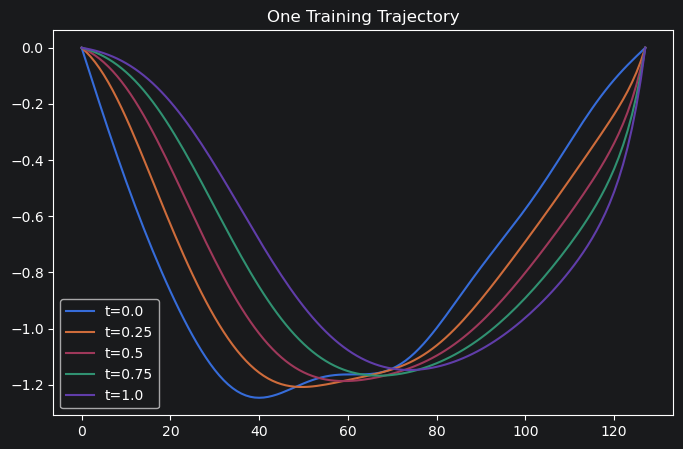

In [162]:
sample = train_data[0]

times = [0.0, 0.25, 0.5, 0.75, 1.0]

plt.figure(figsize=(8,5))

for i in range(5):
    plt.plot(sample[i], label=f"t={times[i]}")

plt.legend()
plt.title("One Training Trajectory")
plt.show()

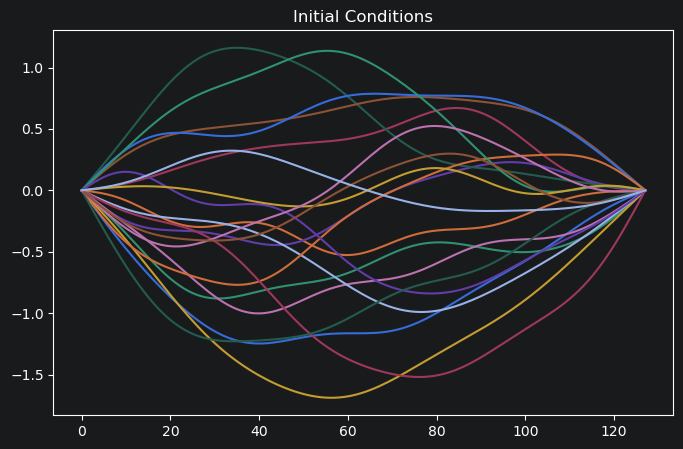

In [163]:
plt.figure(figsize=(8,5))

for i in range(20):
    plt.plot(train_data[i,0])

plt.title("Initial Conditions")
plt.show()

In [164]:
print("Mean:", train_data.mean())
print("Std:", train_data.std())
print("Min:", train_data.min())
print("Max:", train_data.max())

Mean: 0.01848360927516714
Std: 0.6854052543953524
Min: -3.09569802537783
Max: 3.086818723034513


In [165]:
def relative_l2_error(pred, target):

    pred = pred.reshape(pred.shape[0], -1)
    target = target.reshape(target.shape[0], -1)

    num = torch.norm(pred - target, dim=1)
    den = torch.norm(target, dim=1)

    return torch.mean(num / den)

In [166]:
class SpectralConv1d(nn.Module):

    def __init__(self, in_channels, out_channels, modes):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        scale = 1 / (in_channels * out_channels)

        self.weights = nn.Parameter(
            scale * torch.rand(
                in_channels,
                out_channels,
                modes,
                dtype=torch.cfloat
            )
        )

    def compl_mul1d(self, input, weights):

        return torch.einsum(
            "bix,iox->box",
            input,
            weights
        )

    def forward(self, x):

        batchsize = x.shape[0]

        x_ft = torch.fft.rfft(x)

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x.size(-1)//2 + 1,
            device=x.device,
            dtype=torch.cfloat
        )

        out_ft[:, :, :self.modes] = self.compl_mul1d(
            x_ft[:, :, :self.modes],
            self.weights
        )

        x = torch.fft.irfft(
            out_ft,
            n=x.size(-1)
        )

        return x

In [167]:
class FNO1d(nn.Module):

    def __init__(self,
                 modes,
                 width):

        super().__init__()

        self.modes = modes
        self.width = width

        self.fc0 = nn.Linear(2, width)

        self.conv0 = SpectralConv1d(width, width, modes)
        self.conv1 = SpectralConv1d(width, width, modes)
        self.conv2 = SpectralConv1d(width, width, modes)
        self.conv3 = SpectralConv1d(width, width, modes)

        self.w0 = nn.Conv1d(width, width, 1)
        self.w1 = nn.Conv1d(width, width, 1)
        self.w2 = nn.Conv1d(width, width, 1)
        self.w3 = nn.Conv1d(width, width, 1)

        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):

        x = self.fc0(x)

        x = x.permute(0,2,1)

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = F.gelu(x1+x2)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = F.gelu(x1+x2)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = F.gelu(x1+x2)

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1+x2

        x = x.permute(0,2,1)

        x = F.gelu(self.fc1(x))

        x = self.fc2(x)

        return x.squeeze(-1)

In [168]:
class OneToOneDataset(Dataset):

    def __init__(self, data):

        self.u0 = data[:,0,:]
        self.ut = data[:,4,:]

        self.grid = np.linspace(
            0,
            1,
            self.u0.shape[1]
        )

    def __len__(self):
        return len(self.u0)

    def __getitem__(self, idx):

        u0 = self.u0[idx]
        target = self.ut[idx]

        inp = np.stack(
            [u0, self.grid],
            axis=-1
        )

        return (
            torch.tensor(inp, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32)
        )

In [169]:
train_ds = OneToOneDataset(train_data)
val_ds = OneToOneDataset(val_data)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32
)

In [170]:
model = FNO1d(
    modes=16,
    width=64
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

criterion = nn.MSELoss()

In [171]:
def train_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(pred, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [172]:
def validate(model, loader, criterion):

    model.eval()

    total_loss = 0
    total_rel_l2 = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(pred, y)

            rel_l2 = relative_l2_error(pred, y)

            total_loss += loss.item()
            total_rel_l2 += rel_l2.item()

    return (
        total_loss / len(loader),
        total_rel_l2 / len(loader)
    )

In [173]:
epochs = 200

train_losses = []
val_losses = []
val_errors = []

best_error = float("inf")

In [174]:
for epoch in range(epochs):

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_error = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_errors.append(val_error)

    if val_error < best_error:

        best_error = val_error

        torch.save(
            model.state_dict(),
            "task1_fno.pt"
        )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_loss:.6f} | "
            f"Val Error {val_error:.6f}"
        )

Epoch 000 | Train Loss 0.135759 | Val Error 0.274387
Epoch 010 | Train Loss 0.000038 | Val Error 0.017379
Epoch 020 | Train Loss 0.000031 | Val Error 0.017577
Epoch 030 | Train Loss 0.000059 | Val Error 0.043011
Epoch 040 | Train Loss 0.000032 | Val Error 0.017525
Epoch 050 | Train Loss 0.000011 | Val Error 0.005885
Epoch 060 | Train Loss 0.000004 | Val Error 0.004565
Epoch 070 | Train Loss 0.000004 | Val Error 0.004816
Epoch 080 | Train Loss 0.000003 | Val Error 0.003680
Epoch 090 | Train Loss 0.000003 | Val Error 0.004388
Epoch 100 | Train Loss 0.000024 | Val Error 0.007220
Epoch 110 | Train Loss 0.000003 | Val Error 0.003768
Epoch 120 | Train Loss 0.000002 | Val Error 0.003257
Epoch 130 | Train Loss 0.000002 | Val Error 0.003655
Epoch 140 | Train Loss 0.000001 | Val Error 0.003443
Epoch 150 | Train Loss 0.000001 | Val Error 0.002529
Epoch 160 | Train Loss 0.000001 | Val Error 0.002338
Epoch 170 | Train Loss 0.000001 | Val Error 0.002283
Epoch 180 | Train Loss 0.000001 | Val Error 0.

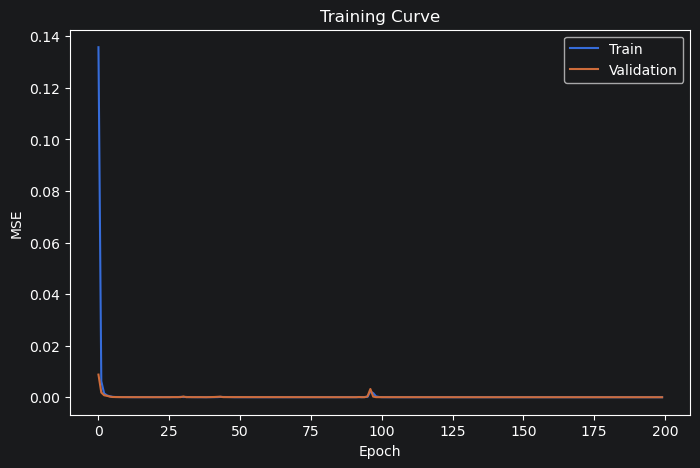

In [175]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.legend()
plt.title("Training Curve")

plt.show()

In [176]:
best_model = FNO1d(
    modes=16,
    width=64
).to(device)

best_model.load_state_dict(
    torch.load("task1_fno.pt")
)

best_model.eval()

FNO1d(
  (fc0): Linear(in_features=2, out_features=64, bias=True)
  (conv0): SpectralConv1d()
  (conv1): SpectralConv1d()
  (conv2): SpectralConv1d()
  (conv3): SpectralConv1d()
  (w0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [177]:
test_ds = OneToOneDataset(test128)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

In [178]:
best_model.eval()

errors = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        pred = best_model(x)

        batch_error = (
            torch.norm(
                pred - y,
                dim=1
            )
            /
            torch.norm(
                y,
                dim=1
            )
        )

        errors.extend(
            batch_error.cpu().numpy()
        )

avg_error = np.mean(errors)

print(
    f"Task 1 Test Relative L2 Error: "
    f"{avg_error:.6f}"
)

Task 1 Test Relative L2 Error: 0.001620


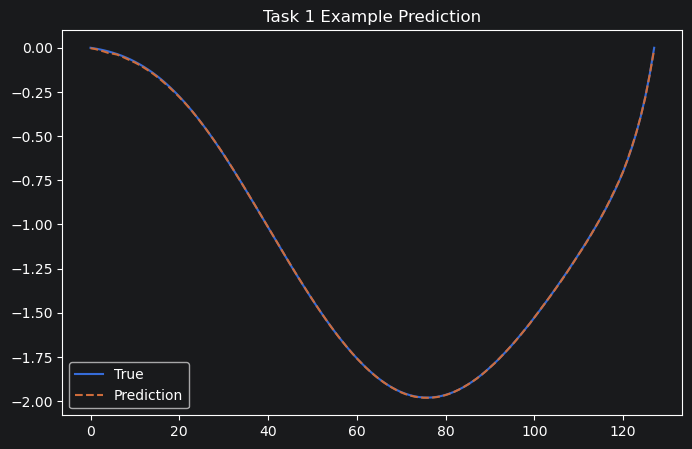

In [179]:
idx = 0

x, y = test_ds[idx]

x = x.unsqueeze(0).to(device)

with torch.no_grad():

    pred = best_model(x)

pred = pred.squeeze().cpu().numpy()
y = y.numpy()

plt.figure(figsize=(8,5))

plt.plot(y, label="True")
plt.plot(pred, "--", label="Prediction")

plt.legend()
plt.title("Task 1 Example Prediction")

plt.show()

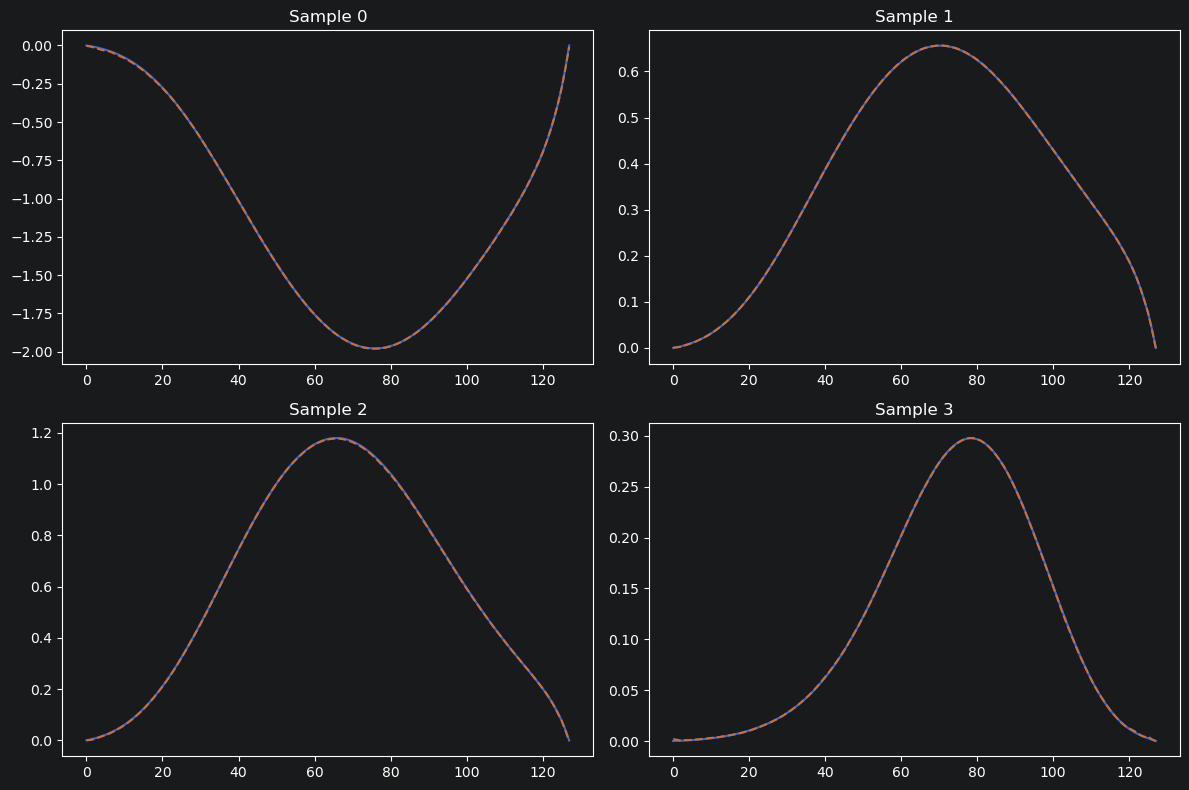

In [180]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, idx in zip(axs.flatten(), [0,1,2,3]):

    x, y = test_ds[idx]

    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        pred = best_model(x)

    pred = pred.squeeze().cpu().numpy()

    ax.plot(y.numpy(), label="True")
    ax.plot(pred, "--", label="Pred")

    ax.set_title(f"Sample {idx}")

plt.tight_layout()
plt.show()

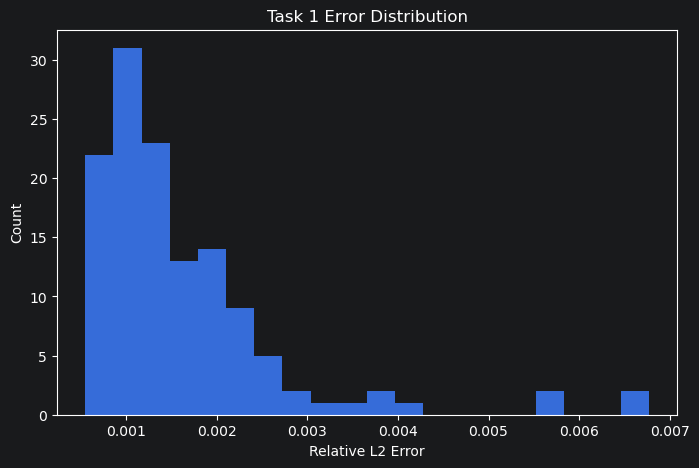

In [181]:
plt.figure(figsize=(8,5))

plt.hist(errors, bins=20)

plt.xlabel("Relative L2 Error")
plt.ylabel("Count")

plt.title("Task 1 Error Distribution")

plt.show()

In [182]:
test32 = np.load("data_test_32.npy")
test64 = np.load("data_test_64.npy")
test96 = np.load("data_test_96.npy")
test128 = np.load("data_test_128.npy")

print("32 :", test32.shape)
print("64 :", test64.shape)
print("96 :", test96.shape)
print("128:", test128.shape)

32 : (128, 5, 32)
64 : (128, 5, 64)
96 : (128, 5, 96)
128: (128, 5, 128)


In [183]:
class ResolutionDataset(Dataset):

    def __init__(self, data):

        self.u0 = data[:, 0, :]
        self.ut = data[:, 4, :]

        self.resolution = self.u0.shape[1]

        self.grid = np.linspace(
            0,
            1,
            self.resolution
        )

    def __len__(self):
        return len(self.u0)

    def __getitem__(self, idx):

        u0 = self.u0[idx]
        target = self.ut[idx]

        inp = np.stack(
            [u0, self.grid],
            axis=-1
        )

        return (
            torch.tensor(inp, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32)
        )

In [184]:
test_loaders = {}

for res, data in zip(
    [32, 64, 96, 128],
    [test32, test64, test96, test128]
):

    ds = ResolutionDataset(data)

    loader = DataLoader(
        ds,
        batch_size=32,
        shuffle=False
    )

    test_loaders[res] = loader

In [185]:
def evaluate_resolution(model, loader):

    model.eval()

    errors = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            batch_errors = (
                torch.norm(pred - y, dim=1)
                /
                torch.norm(y, dim=1)
            )

            errors.extend(
                batch_errors.cpu().numpy()
            )

    return np.mean(errors)

In [186]:
resolution_errors = {}

for res, loader in test_loaders.items():

    error = evaluate_resolution(
        best_model,
        loader
    )

    resolution_errors[res] = error

    print(
        f"Resolution {res:3d} : "
        f"Relative L2 Error = {error:.6f}"
    )

Resolution  32 : Relative L2 Error = 0.076242
Resolution  64 : Relative L2 Error = 0.027220
Resolution  96 : Relative L2 Error = 0.008536
Resolution 128 : Relative L2 Error = 0.001620


In [187]:
import pandas as pd

results_df = pd.DataFrame(
    {
        "Resolution": list(resolution_errors.keys()),
        "Relative L2 Error": list(resolution_errors.values())
    }
)

results_df

,Resolution,Relative L2 Error
0,32,0.076242
1,64,0.027220
2,96,0.008536
3,128,0.001620


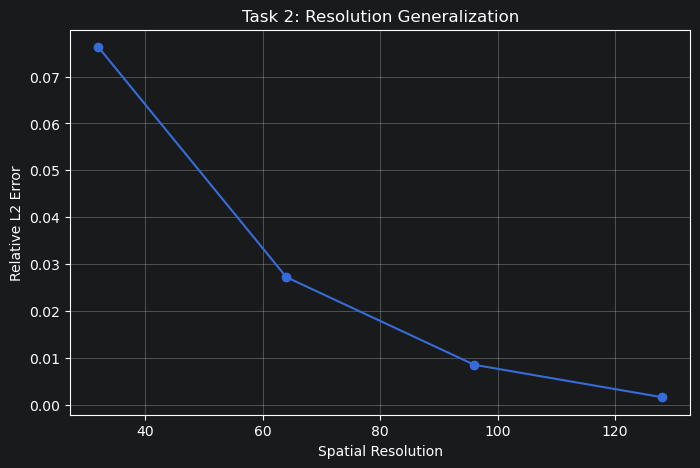

In [188]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Resolution"],
    results_df["Relative L2 Error"],
    marker="o"
)

plt.xlabel("Spatial Resolution")
plt.ylabel("Relative L2 Error")

plt.title("Task 2: Resolution Generalization")

plt.grid(True)

plt.show()

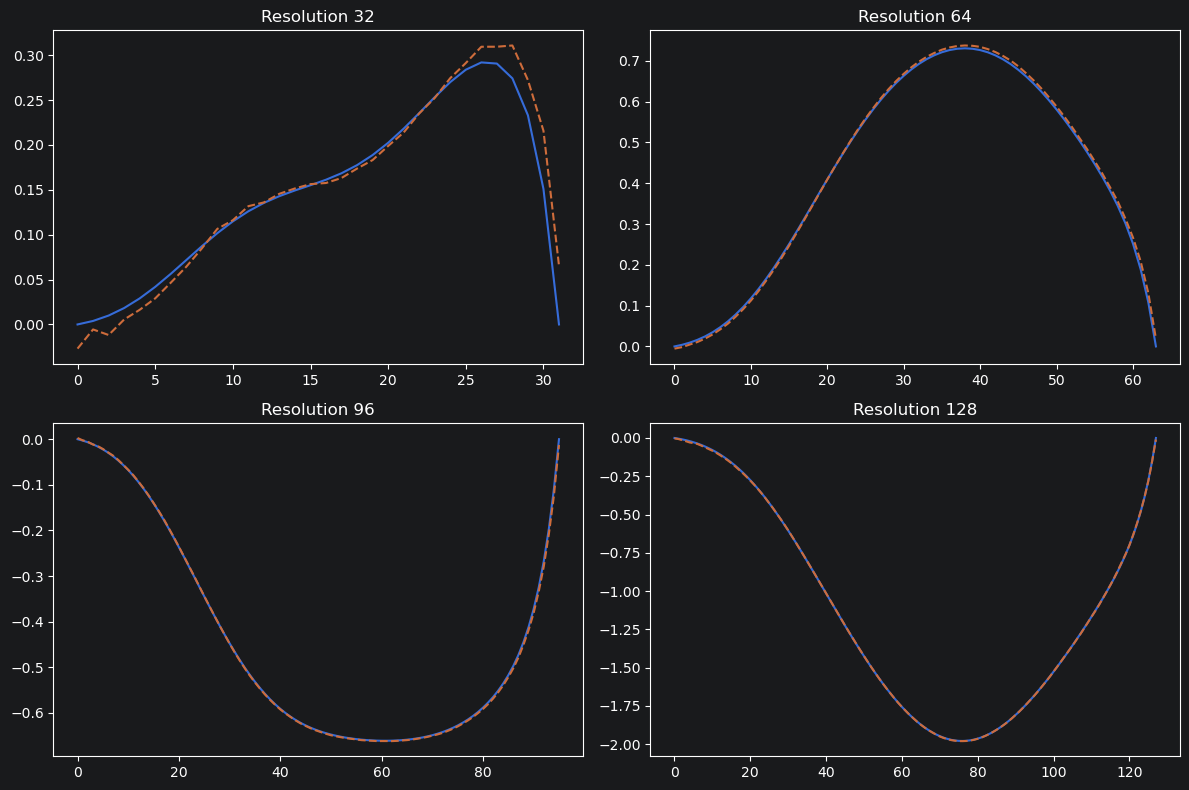

In [189]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

resolutions = [32, 64, 96, 128]

for ax, res in zip(axs.flatten(), resolutions):

    dataset = ResolutionDataset(
        {
            32: test32,
            64: test64,
            96: test96,
            128: test128
        }[res]
    )

    x, y = dataset[0]

    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        pred = best_model(x)

    pred = pred.squeeze().cpu().numpy()

    ax.plot(y.numpy(), label="True")
    ax.plot(pred, "--", label="Prediction")

    ax.set_title(f"Resolution {res}")

plt.tight_layout()
plt.show()

In [190]:
times = np.array(
    [0.0, 0.25, 0.50, 0.75, 1.0],
    dtype=np.float32
)

print(times)

[0.   0.25 0.5  0.75 1.  ]


In [191]:
class All2AllDataset(Dataset):

    def __init__(self, data):

        self.samples = []

        resolution = data.shape[-1]

        grid = np.linspace(
            0,
            1,
            resolution
        )

        for traj in data:

            u0 = traj[0]

            for time_idx, t in enumerate(times):

                target = traj[time_idx]

                self.samples.append(
                    (
                        u0.astype(np.float32),
                        t,
                        target.astype(np.float32),
                        grid.astype(np.float32)
                    )
                )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        u0, t, target, grid = self.samples[idx]

        t_channel = np.full_like(
            grid,
            t
        )

        inp = np.stack(
            [
                u0,
                grid,
                t_channel
            ],
            axis=-1
        )

        return (
            torch.tensor(inp, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32)
        )

In [192]:
all_train_ds = All2AllDataset(
    train_data
)

all_val_ds = All2AllDataset(
    val_data
)

print("Train samples:", len(all_train_ds))
print("Val samples:", len(all_val_ds))

Train samples: 5120
Val samples: 160


In [193]:
all_train_loader = DataLoader(
    all_train_ds,
    batch_size=32,
    shuffle=True
)

all_val_loader = DataLoader(
    all_val_ds,
    batch_size=32,
    shuffle=False
)

In [194]:
class FNO1d_Time(nn.Module):

    def __init__(self,
                 modes,
                 width):

        super().__init__()

        self.modes = modes
        self.width = width

        self.fc0 = nn.Linear(
            3,
            width
        )

        self.conv0 = SpectralConv1d(
            width,
            width,
            modes
        )

        self.conv1 = SpectralConv1d(
            width,
            width,
            modes
        )

        self.conv2 = SpectralConv1d(
            width,
            width,
            modes
        )

        self.conv3 = SpectralConv1d(
            width,
            width,
            modes
        )

        self.w0 = nn.Conv1d(
            width,
            width,
            1
        )

        self.w1 = nn.Conv1d(
            width,
            width,
            1
        )

        self.w2 = nn.Conv1d(
            width,
            width,
            1
        )

        self.w3 = nn.Conv1d(
            width,
            width,
            1
        )

        self.fc1 = nn.Linear(
            width,
            128
        )

        self.fc2 = nn.Linear(
            128,
            1
        )

    def forward(self, x):

        x = self.fc0(x)

        x = x.permute(0,2,1)

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = F.gelu(x1+x2)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = F.gelu(x1+x2)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = F.gelu(x1+x2)

        x1 = self.conv3(x)
        x2 = self.w3(x)

        x = x1+x2

        x = x.permute(0,2,1)

        x = F.gelu(
            self.fc1(x)
        )

        x = self.fc2(x)

        return x.squeeze(-1)

In [195]:
time_model = FNO1d_Time(
    modes=16,
    width=64
).to(device)

optimizer = torch.optim.Adam(
    time_model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

criterion = nn.MSELoss()

In [196]:
def validate_time_model(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0
    total_rel_l2 = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            pred = model(x)

            loss = criterion(
                pred,
                y
            )

            rel_l2 = relative_l2_error(
                pred,
                y
            )

            total_loss += loss.item()
            total_rel_l2 += rel_l2.item()

    return (
        total_loss / len(loader),
        total_rel_l2 / len(loader)
    )

In [197]:
def train_time_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    total_loss = 0

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)

        loss = criterion(
            pred,
            y
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [198]:
epochs = 200

train_losses_time = []
val_losses_time = []
val_errors_time = []

best_time_error = float("inf")

In [199]:
for epoch in range(epochs):

    train_loss = train_time_epoch(
        time_model,
        all_train_loader,
        optimizer,
        criterion
    )

    val_loss, val_error = validate_time_model(
        time_model,
        all_val_loader,
        criterion
    )

    scheduler.step()

    train_losses_time.append(
        train_loss
    )

    val_losses_time.append(
        val_loss
    )

    val_errors_time.append(
        val_error
    )

    if val_error < best_time_error:

        best_time_error = val_error

        torch.save(
            time_model.state_dict(),
            "task3_fno.pt"
        )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_loss:.6f} | "
            f"Val Error {val_error:.6f}"
        )

Epoch 000 | Train Loss 0.037308 | Val Error 0.090381
Epoch 010 | Train Loss 0.000297 | Val Error 0.048271
Epoch 020 | Train Loss 0.000305 | Val Error 0.040365
Epoch 030 | Train Loss 0.000025 | Val Error 0.011946
Epoch 040 | Train Loss 0.000012 | Val Error 0.007003
Epoch 050 | Train Loss 0.000018 | Val Error 0.006000
Epoch 060 | Train Loss 0.000027 | Val Error 0.014193
Epoch 070 | Train Loss 0.000007 | Val Error 0.004840
Epoch 080 | Train Loss 0.000054 | Val Error 0.020066
Epoch 090 | Train Loss 0.000182 | Val Error 0.010439
Epoch 100 | Train Loss 0.000002 | Val Error 0.003088
Epoch 110 | Train Loss 0.000003 | Val Error 0.003665
Epoch 120 | Train Loss 0.000009 | Val Error 0.004669
Epoch 130 | Train Loss 0.000007 | Val Error 0.003463
Epoch 140 | Train Loss 0.000006 | Val Error 0.006915
Epoch 150 | Train Loss 0.000001 | Val Error 0.002639
Epoch 160 | Train Loss 0.000011 | Val Error 0.005156
Epoch 170 | Train Loss 0.000002 | Val Error 0.002818
Epoch 180 | Train Loss 0.000004 | Val Error 0.

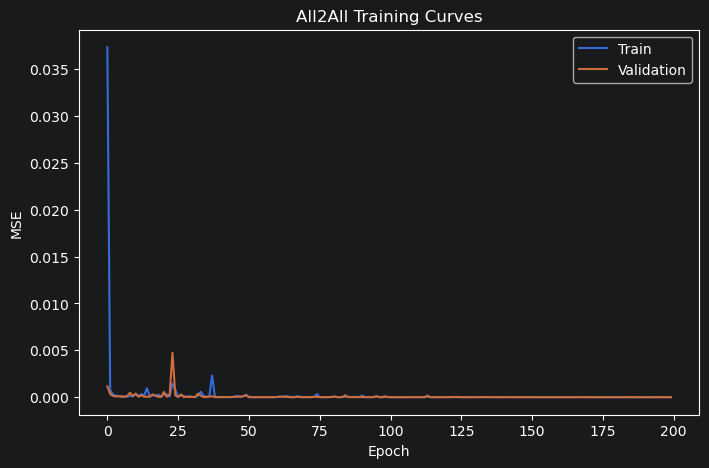

In [200]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses_time,
    label="Train"
)

plt.plot(
    val_losses_time,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.title(
    "All2All Training Curves"
)

plt.legend()

plt.show()

In [201]:
best_time_model = FNO1d_Time(
    modes=16,
    width=64
).to(device)

best_time_model.load_state_dict(
    torch.load("task3_fno.pt")
)

best_time_model.eval()

FNO1d_Time(
  (fc0): Linear(in_features=3, out_features=64, bias=True)
  (conv0): SpectralConv1d()
  (conv1): SpectralConv1d()
  (conv2): SpectralConv1d()
  (conv3): SpectralConv1d()
  (w0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [202]:
class TimeSpecificDataset(Dataset):

    def __init__(self, data, time_idx):

        self.u0 = data[:, 0, :]
        self.target = data[:, time_idx, :]

        self.t = times[time_idx]

        self.grid = np.linspace(
            0,
            1,
            self.u0.shape[1]
        )

    def __len__(self):
        return len(self.u0)

    def __getitem__(self, idx):

        u0 = self.u0[idx]

        t_channel = np.full_like(
            self.grid,
            self.t
        )

        inp = np.stack(
            [
                u0,
                self.grid,
                t_channel
            ],
            axis=-1
        )

        return (
            torch.tensor(inp, dtype=torch.float32),
            torch.tensor(
                self.target[idx],
                dtype=torch.float32
            )
        )

In [203]:
test_t1_ds = TimeSpecificDataset(
    test128,
    time_idx=4
)

test_t1_loader = DataLoader(
    test_t1_ds,
    batch_size=32,
    shuffle=False
)

In [204]:
errors_t1 = []

best_time_model.eval()

with torch.no_grad():

    for x, y in test_t1_loader:

        x = x.to(device)
        y = y.to(device)

        pred = best_time_model(x)

        batch_errors = (
            torch.norm(
                pred - y,
                dim=1
            )
            /
            torch.norm(
                y,
                dim=1
            )
        )

        errors_t1.extend(
            batch_errors.cpu().numpy()
        )

task3_t1_error = np.mean(errors_t1)

print(
    f"Task 3 Test Error at t=1: "
    f"{task3_t1_error:.6f}"
)

Task 3 Test Error at t=1: 0.002021


In [205]:
print(
    f"Task 1 Error : {avg_error:.6f}"
)

print(
    f"Task 3 Error : {task3_t1_error:.6f}"
)

improvement = (
    (avg_error - task3_t1_error)
    /
    avg_error
) * 100

print(
    f"Improvement : {improvement:.2f}%"
)

Task 1 Error : 0.001620
Task 3 Error : 0.002021
Improvement : -24.77%


In [206]:
time_errors = {}

for time_idx in [1, 2, 3, 4]:

    dataset = TimeSpecificDataset(
        test128,
        time_idx
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    errors = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            pred = best_time_model(x)

            batch_errors = (
                torch.norm(
                    pred - y,
                    dim=1
                )
                /
                torch.norm(
                    y,
                    dim=1
                )
            )

            errors.extend(
                batch_errors.cpu().numpy()
            )

    time_errors[
        times[time_idx]
    ] = np.mean(errors)

In [207]:
for t, err in time_errors.items():

    print(
        f"Time {t:.2f} : "
        f"Relative L2 Error = "
        f"{err:.6f}"
    )

Time 0.25 : Relative L2 Error = 0.001562
Time 0.50 : Relative L2 Error = 0.001547
Time 0.75 : Relative L2 Error = 0.001717
Time 1.00 : Relative L2 Error = 0.002021


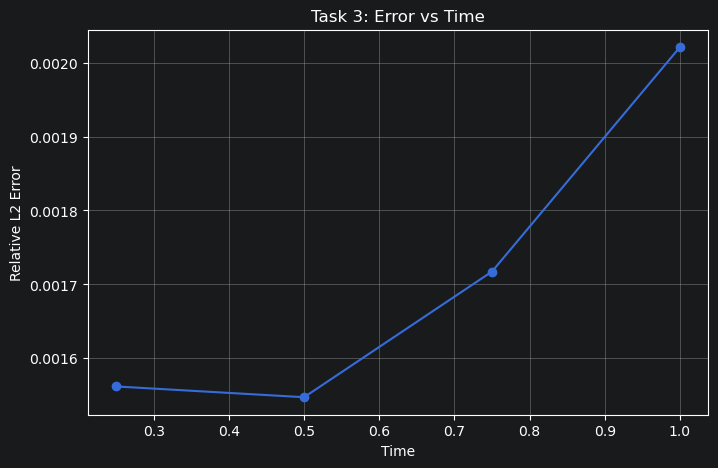

In [208]:
plt.figure(figsize=(8,5))

plt.plot(
    list(time_errors.keys()),
    list(time_errors.values()),
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Relative L2 Error")

plt.title(
    "Task 3: Error vs Time"
)

plt.grid(True)

plt.show()

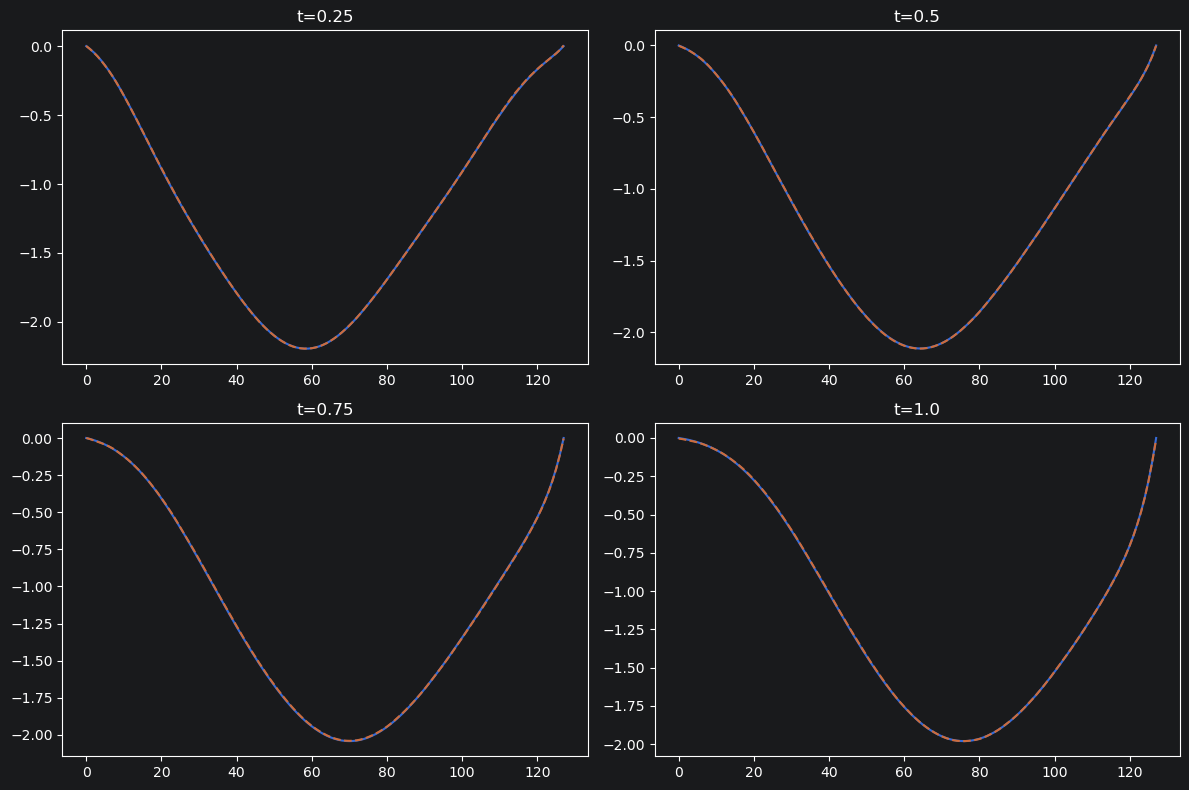

In [209]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

for ax, time_idx in zip(
    axs.flatten(),
    [1, 2, 3, 4]
):

    dataset = TimeSpecificDataset(
        test128,
        time_idx
    )

    x, y = dataset[0]

    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        pred = best_time_model(x)

    pred = pred.squeeze().cpu().numpy()

    ax.plot(
        y.numpy(),
        label="True"
    )

    ax.plot(
        pred,
        "--",
        label="Prediction"
    )

    ax.set_title(
        f"t={times[time_idx]}"
    )

plt.tight_layout()
plt.show()

In [210]:
finetune_train = np.load(
    "data_finetune_train_unknown_128.npy"
)

finetune_val = np.load(
    "data_finetune_val_unknown_128.npy"
)

test_unknown = np.load(
    "data_test_unknown_128.npy"
)

print("Finetune Train:", finetune_train.shape)
print("Finetune Val  :", finetune_val.shape)
print("Test Unknown  :", test_unknown.shape)

Finetune Train: (32, 5, 128)
Finetune Val  : (8, 5, 128)
Test Unknown  : (128, 5, 128)


In [211]:
unknown_test_t1 = TimeSpecificDataset(
    test_unknown,
    time_idx=4
)

unknown_test_loader = DataLoader(
    unknown_test_t1,
    batch_size=32,
    shuffle=False
)

In [212]:
zero_shot_errors = []

best_time_model.eval()

with torch.no_grad():

    for x, y in unknown_test_loader:

        x = x.to(device)
        y = y.to(device)

        pred = best_time_model(x)

        batch_errors = (
            torch.norm(pred - y, dim=1)
            /
            torch.norm(y, dim=1)
        )

        zero_shot_errors.extend(
            batch_errors.cpu().numpy()
        )

zero_shot_error = np.mean(
    zero_shot_errors
)

print(
    f"Zero-Shot Error: "
    f"{zero_shot_error:.6f}"
)

Zero-Shot Error: 0.015477


In [213]:
finetune_train_ds = All2AllDataset(
    finetune_train
)

finetune_val_ds = All2AllDataset(
    finetune_val
)

print(
    len(finetune_train_ds),
    len(finetune_val_ds)
)

160 40


In [214]:
finetune_train_loader = DataLoader(
    finetune_train_ds,
    batch_size=16,
    shuffle=True
)

finetune_val_loader = DataLoader(
    finetune_val_ds,
    batch_size=16,
    shuffle=False
)

In [215]:
finetuned_model = FNO1d_Time(
    modes=16,
    width=64
).to(device)

finetuned_model.load_state_dict(
    torch.load("task3_fno.pt")
)

<All keys matched successfully>

In [216]:
finetune_optimizer = torch.optim.Adam(
    finetuned_model.parameters(),
    lr=1e-4
)

finetune_scheduler = (
    torch.optim.lr_scheduler.StepLR(
        finetune_optimizer,
        step_size=20,
        gamma=0.5
    )
)

In [217]:
finetune_epochs = 100

finetune_train_losses = []
finetune_val_losses = []
finetune_val_errors = []

best_finetune_error = float("inf")

In [218]:
for epoch in range(finetune_epochs):

    train_loss = train_time_epoch(
        finetuned_model,
        finetune_train_loader,
        finetune_optimizer,
        criterion
    )

    val_loss, val_error = validate_time_model(
        finetuned_model,
        finetune_val_loader,
        criterion
    )

    finetune_scheduler.step()

    finetune_train_losses.append(
        train_loss
    )

    finetune_val_losses.append(
        val_loss
    )

    finetune_val_errors.append(
        val_error
    )

    if val_error < best_finetune_error:

        best_finetune_error = val_error

        torch.save(
            finetuned_model.state_dict(),
            "finetuned_fno.pt"
        )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_loss:.6f} | "
            f"Val Error {val_error:.6f}"
        )

Epoch 000 | Train Loss 0.000027 | Val Error 0.014223
Epoch 010 | Train Loss 0.000008 | Val Error 0.010528
Epoch 020 | Train Loss 0.000007 | Val Error 0.010437
Epoch 030 | Train Loss 0.000004 | Val Error 0.009362
Epoch 040 | Train Loss 0.000004 | Val Error 0.008872
Epoch 050 | Train Loss 0.000004 | Val Error 0.008677
Epoch 060 | Train Loss 0.000003 | Val Error 0.008646
Epoch 070 | Train Loss 0.000003 | Val Error 0.008598
Epoch 080 | Train Loss 0.000003 | Val Error 0.008460
Epoch 090 | Train Loss 0.000003 | Val Error 0.008407


In [219]:
best_finetuned_model = FNO1d_Time(
    modes=16,
    width=64
).to(device)

best_finetuned_model.load_state_dict(
    torch.load("finetuned_fno.pt")
)

best_finetuned_model.eval()

FNO1d_Time(
  (fc0): Linear(in_features=3, out_features=64, bias=True)
  (conv0): SpectralConv1d()
  (conv1): SpectralConv1d()
  (conv2): SpectralConv1d()
  (conv3): SpectralConv1d()
  (w0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [220]:
finetuned_errors = []

with torch.no_grad():

    for x, y in unknown_test_loader:

        x = x.to(device)
        y = y.to(device)

        pred = best_finetuned_model(x)

        batch_errors = (
            torch.norm(
                pred - y,
                dim=1
            )
            /
            torch.norm(
                y,
                dim=1
            )
        )

        finetuned_errors.extend(
            batch_errors.cpu().numpy()
        )

finetuned_error = np.mean(
    finetuned_errors
)

print(
    f"Finetuned Error: "
    f"{finetuned_error:.6f}"
)

Finetuned Error: 0.008027


In [221]:
improvement = (
    (zero_shot_error - finetuned_error)
    /
    zero_shot_error
) * 100

print(
    f"Zero-shot Error : {zero_shot_error:.6f}"
)

print(
    f"Finetuned Error : {finetuned_error:.6f}"
)

print(
    f"Improvement     : {improvement:.2f}%"
)

Zero-shot Error : 0.015477
Finetuned Error : 0.008027
Improvement     : 48.14%


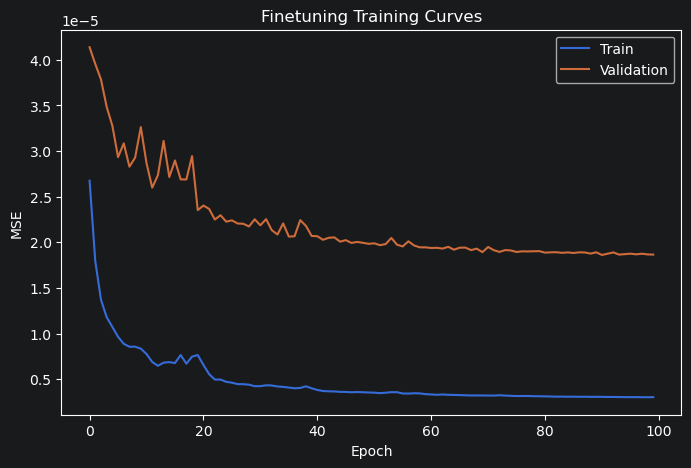

In [222]:
plt.figure(figsize=(8,5))

plt.plot(
    finetune_train_losses,
    label="Train"
)

plt.plot(
    finetune_val_losses,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.title(
    "Finetuning Training Curves"
)

plt.legend()

plt.show()

In [223]:
scratch_model = FNO1d_Time(
    modes=16,
    width=64
).to(device)

In [224]:
scratch_optimizer = torch.optim.Adam(
    scratch_model.parameters(),
    lr=1e-3
)

scratch_scheduler = (
    torch.optim.lr_scheduler.StepLR(
        scratch_optimizer,
        step_size=20,
        gamma=0.5
    )
)

criterion = nn.MSELoss()

In [225]:
scratch_epochs = 100

scratch_train_losses = []
scratch_val_losses = []
scratch_val_errors = []

best_scratch_error = float("inf")

In [226]:
for epoch in range(scratch_epochs):

    train_loss = train_time_epoch(
        scratch_model,
        finetune_train_loader,
        scratch_optimizer,
        criterion
    )

    val_loss, val_error = validate_time_model(
        scratch_model,
        finetune_val_loader,
        criterion
    )

    scratch_scheduler.step()

    scratch_train_losses.append(
        train_loss
    )

    scratch_val_losses.append(
        val_loss
    )

    scratch_val_errors.append(
        val_error
    )

    if val_error < best_scratch_error:

        best_scratch_error = val_error

        torch.save(
            scratch_model.state_dict(),
            "scratch_fno.pt"
        )

    if epoch % 10 == 0:

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {train_loss:.6f} | "
            f"Val Error {val_error:.6f}"
        )

Epoch 000 | Train Loss 0.121079 | Val Error 0.815718
Epoch 010 | Train Loss 0.001828 | Val Error 0.131270
Epoch 020 | Train Loss 0.000415 | Val Error 0.069790
Epoch 030 | Train Loss 0.000168 | Val Error 0.049475
Epoch 040 | Train Loss 0.000097 | Val Error 0.039884
Epoch 050 | Train Loss 0.000076 | Val Error 0.036143
Epoch 060 | Train Loss 0.000063 | Val Error 0.032598
Epoch 070 | Train Loss 0.000056 | Val Error 0.031486
Epoch 080 | Train Loss 0.000049 | Val Error 0.030008
Epoch 090 | Train Loss 0.000046 | Val Error 0.029671


In [227]:
best_scratch_model = FNO1d_Time(
    modes=16,
    width=64
).to(device)

best_scratch_model.load_state_dict(
    torch.load("scratch_fno.pt")
)

best_scratch_model.eval()

FNO1d_Time(
  (fc0): Linear(in_features=3, out_features=64, bias=True)
  (conv0): SpectralConv1d()
  (conv1): SpectralConv1d()
  (conv2): SpectralConv1d()
  (conv3): SpectralConv1d()
  (w0): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w2): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (w3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [228]:
scratch_errors = []

with torch.no_grad():

    for x, y in unknown_test_loader:

        x = x.to(device)
        y = y.to(device)

        pred = best_scratch_model(x)

        batch_errors = (
            torch.norm(
                pred - y,
                dim=1
            )
            /
            torch.norm(
                y,
                dim=1
            )
        )

        scratch_errors.extend(
            batch_errors.cpu().numpy()
        )

scratch_error = np.mean(
    scratch_errors
)

print(
    f"Scratch Model Error: "
    f"{scratch_error:.6f}"
)

Scratch Model Error: 0.039727


In [229]:
import pandas as pd

final_results = pd.DataFrame(
{
    "Model":[
        "Task 1 One2One",
        "Task 3 All2All",
        "Zero-Shot",
        "Finetuned",
        "Scratch"
    ],
    "Relative L2 Error":[
        avg_error,
        task3_t1_error,
        zero_shot_error,
        finetuned_error,
        scratch_error
    ]
})

final_results

,Model,Relative L2 Error
0,Task 1 One2One,0.001620
1,Task 3 All2All,0.002021
2,Zero-Shot,0.015477
3,Finetuned,0.008027
4,Scratch,0.039727


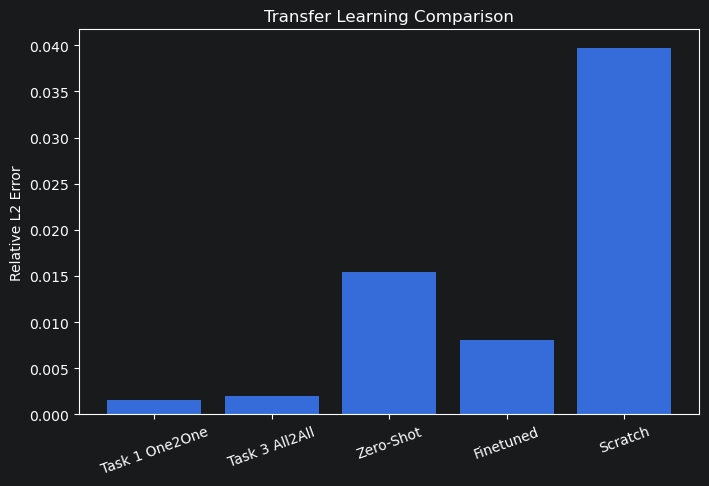

In [230]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["Model"],
    final_results["Relative L2 Error"]
)

plt.ylabel("Relative L2 Error")

plt.title(
    "Transfer Learning Comparison"
)

plt.xticks(rotation=20)

plt.show()

In [231]:
gain = (
    (scratch_error - finetuned_error)
    /
    scratch_error
) * 100

print(
    f"Transfer Learning Gain: "
    f"{gain:.2f}%"
)

Transfer Learning Gain: 79.80%
